# Laboratory work 2. ANN.

## Importing the required libraries

In [7]:
# Importing necessary libraries
import numpy as np
import csv
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Library to split data
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

# KNN, Decision tree, Random Forest algorithms
from sklearn.neighbors import KNeighborsRegressor
from sklearn import tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Model performance evaluation imports
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report, precision_score, f1_score, recall_score, accuracy_score
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score

# To ignore warnings
import warnings
warnings.filterwarnings('ignore')

## Loading the dataset

In [8]:
# Reading the dataset
data = pd.read_csv('apartments.csv')
df = data.copy()

In [9]:
# Print the first 5 rows with columns as rows for quick overview of the data
df.head().T

,0,1,2,3,4
id,5668640009,5668639818,5668639686,5668639659,5668639374
category,housing/rent/apartment,housing/rent/apartment,housing/rent/apartment,housing/rent/apartment,housing/rent/apartment
title,One BR 507 & 509 Esplanade,Three BR 146 Lochview Drive,Three BR 3101 Morningside Drive,Two BR 209 Aegean Way,One BR 4805 Marquette NE
body,"This unit is located at 507 & 509 Esplanade, R...","This unit is located at 146 Lochview Drive, Ne...",This unit is located at 3101 Morningside Drive...,"This unit is located at 209 Aegean Way, Vacavi...","This unit is located at 4805 Marquette NE, Alb..."
amenities,NaN,NaN,NaN,NaN,NaN
bathrooms,1.0,1.5,2.0,1.0,1.0
bedrooms,1.0,3.0,3.0,2.0,1.0
currency,USD,USD,USD,USD,USD
fee,No,No,No,No,No
has_photo,Thumbnail,Thumbnail,Thumbnail,Thumbnail,Thumbnail


## Checking the info of the data

In [10]:
# Use info() to print a concise summary of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 22 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   id             100000 non-null  int64  
 1   category       100000 non-null  object 
 2   title          100000 non-null  object 
 3   body           100000 non-null  object 
 4   amenities      83903 non-null   object 
 5   bathrooms      99930 non-null   float64
 6   bedrooms       99869 non-null   float64
 7   currency       99993 non-null   object 
 8   fee            99993 non-null   object 
 9   has_photo      99993 non-null   object 
 10  pets_allowed   39255 non-null   object 
 11  price          99992 non-null   float64
 12  price_display  99992 non-null   object 
 13  price_type     99993 non-null   object 
 14  square_feet    99993 non-null   float64
 15  address        7943 non-null    object 
 16  cityname       99691 non-null   object 
 17  state          99691 non-null 

In [11]:
# Check the number of rows and columns
df.shape

(100000, 22)

<b> Observations: </b>

- There are 100000 observations and 22 columns in the data.
- Not all the columns have 100000 non-null values, which means there are missing values in the data.

## Data Quality Report

### Numerical data

In [12]:
def data_quality_numeric(data):
    # Descriptive statistics transformed
    stats = data.describe().T

    # Create missing percentage and cardinality columns for data quality report
    stats['% Miss'] = data.isnull().mean() * 100
    stats['Card.'] = data.nunique()
    
    # Rename the descriptive stats columns to match data quality report
    stats = stats.rename(columns={'count': 'Count', 
                                  'mean': 'Mean', 
                                  'std': 'Std. Dev.', 
                                  'min': 'Min', 
                                  '25%': 'Q1',
                                  '50%': 'Median', 
                                  '75%': 'Q3', 
                                  'max': 'Max'})

    # Reorder columns
    stats = stats[['Count', '% Miss', 'Card.', 'Min', 'Q1', 'Mean', 'Median', 'Q3', 'Max', 'Std. Dev.']]
    return stats
    
data_quality_numeric(df)

,Count,% Miss,Card.,Min,Q1,Mean,Median,Q3,Max,Std. Dev.
id,100000.0,0.000,99916,5.121046e+09,5.197954e+09,5.358815e+09,5.508674e+09,5.509009e+09,5.669439e+09,1.846077e+08
bathrooms,99930.0,0.070,16,1.000000e+00,1.000000e+00,1.445372e+00,1.000000e+00,2.000000e+00,9.000000e+00,5.468777e-01
bedrooms,99869.0,0.131,10,0.000000e+00,1.000000e+00,1.727934e+00,2.000000e+00,2.000000e+00,9.000000e+00,7.489240e-01
price,99992.0,0.008,3691,1.000000e+02,1.014000e+03,1.527184e+03,1.350000e+03,1.795000e+03,5.250000e+04,9.032529e+02
square_feet,99993.0,0.007,2540,1.010000e+02,7.290000e+02,9.564238e+02,9.000000e+02,1.115000e+03,5.000000e+04,4.170985e+02
latitude,99968.0,0.032,7215,1.957380e+01,3.374960e+01,3.695005e+01,3.723100e+01,3.995420e+01,6.483320e+01,4.599818e+00
longitude,99968.0,0.032,7274,-1.593698e+02,-1.047919e+02,-9.155456e+01,-8.455190e+01,-7.757670e+01,-6.877880e+01,1.581982e+01
time,99993.0,0.007,75636,1.544174e+09,1.550832e+09,1.559695e+09,1.568745e+09,1.568767e+09,1.577391e+09,1.104320e+07


### Categorical data

In [13]:
def data_quality_categorical(data):
    categorical = data.select_dtypes(include=['object'])
    stats = []

    for col in categorical.columns:
        feature = categorical[col]
        value_counts = feature.value_counts(dropna=True)
        
        # Count existing values
        count = feature.count()

        # Count missing value percentage
        missing_perc = feature.isnull().mean() * 100

        # Check cardinality
        card = feature.nunique()

        # Get mode and it's frequency if exists
        mode = feature.mode()
        if len(value_counts) > 0:
            mode_val = value_counts.index[0]
            mode_freq = value_counts.iloc[0]
        else:
            mode_val = None
            mode_freq = 0

        # Get mode percentage if exists
        if count > 0:
            mode_perc = mode_freq / count * 100
        else:
            mode_perc = 0

        # Get second mode and it's frequency if exists
        if len(value_counts) > 1:
            mode_val_2 = value_counts.index[1]
            mode_freq_2 = value_counts.iloc[1]
        else:
            mode_val_2 = None
            mode_freq_2 = 0

        # Get second mode percentage if exists
        if count > 0 and len(value_counts) > 1:
            mode_perc_2 = mode_freq_2 / count * 100
        else:
            mode_perc_2 = 0
        
        stats.append({'Feature': col,
                      'Count': count,
                      '% Miss': missing_perc,
                      'Card.': card,
                      'Mode': mode_val,
                      'Mode Freq': mode_freq,
                      'Mode %': mode_perc,
                      '2nd Mode': mode_val_2,
                      '2nd Mode Freq': mode_freq_2,
                      '2nd Mode %': mode_perc_2})
    return pd.DataFrame(stats)

data_quality_categorical(df)

,Feature,Count,% Miss,Card.,Mode,Mode Freq,Mode %,2nd Mode,2nd Mode Freq,2nd Mode %
0,category,100000,0.000,7,housing/rent/apartment,99939,99.939000,housing/rent/commercial/retail,42,0.042000
1,title,100000,0.000,58730,Apartment in great location,1068,1.068000,Apartment in prime location,1034,1.034000
2,body,100000,0.000,94950,"When searching for a pet-friendly One-, Two- a...",45,0.045000,"Welcome Apartment Homes, where quality apartme...",37,0.037000
3,amenities,83903,16.097,9849,Parking,6210,7.401404,"Parking,Storage",2119,2.525535
4,currency,99993,0.007,1,USD,99993,100.000000,None,0,0.000000
5,fee,99993,0.007,2,No,99792,99.798986,Yes,201,0.201014
6,has_photo,99993,0.007,3,Yes,56250,56.253938,Thumbnail,34474,34.476413
7,pets_allowed,39255,60.745,4,"Cats,Dogs",37278,94.963699,Cats,1849,4.710228
8,price_display,99992,0.008,3722,"$1,350",576,0.576046,$850,548,0.548044
9,price_type,99993,0.007,3,Monthly,99989,99.996000,Weekly,3,0.003000


### Removing duplicates

In [14]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

### Missing values

In [15]:
# Drop address as a lot of missing values (92%)
df = df.drop(columns=['address'])

In [16]:
# Drop state and city name since we have coordinates for location
df = df.drop(columns=['state', 'cityname'])

In [17]:
# Since price and price display only have a few missing values, we can drop them
df = df.dropna(subset=['price', 'price_display'])

In [18]:
# Since only a few (32 each) missing values for lonitude and latitude, we can drop them 
df = df.dropna(subset=['latitude', 'longitude'])

In [19]:
# Fill missing values with median for bedrooms, bathrooms and sqr feet columns as they are important for modelling
df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].median())
df['bedrooms'] = df['bedrooms'].fillna(df['bedrooms'].median())
df['square_feet'] = df['square_feet'].fillna(df['square_feet'].median())

### Unique values

In [20]:
# Checking the number of unique values in each column
df.nunique().sort_values(ascending=False)

id               99883
body             94919
time             75623
title            58703
amenities         9845
longitude         7274
latitude          7215
price_display     3722
price             3691
square_feet       2539
source              25
bathrooms           16
bedrooms            10
category             7
pets_allowed         4
has_photo            3
price_type           3
fee                  2
currency             1
dtype: int64

<b> Observations: </b>
- Id, title, body have almost all unique values, they are either identifiers or free-text. We can drop these columns as they would not add any value to our analysis.
- Amenities has many unique combinations of features.
- Category, fee, has_photo, pets_allowed, price_type all have a small number of unique values, suitable for one-hot encoding or label encoding.
- Bedrooms, bathrooms, price, price_display, square_feet, latitude, longitude are numerical values and can be used directly for analysis.
- Currency has only one value, it is likely not informative and could be dropped.

In [21]:
# Drop these columns as they do not add value to the analysis
df = df.drop(columns=['id', 'title', 'body', 'currency'])

In [22]:
# Convert time from seconds to human-readable datetime
df['time_formatted'] = pd.to_datetime(df['time'], unit='s')

# Extract the year
df['year'] = df['time_formatted'].dt.year
# Extract the month
df['month'] = df['time_formatted'].dt.month

# Drop the time column
df = df.drop(columns=['time'])

In [23]:
df.isna().sum()

category              0
amenities         16068
bathrooms             0
bedrooms              0
fee                   0
has_photo             0
pets_allowed      60673
price                 0
price_display         0
price_type            0
square_feet           0
latitude              0
longitude             0
source                0
time_formatted        0
year                  0
month                 0
dtype: int64

- For pets allowed and amenities, we need to fill in the missing values.
- For missing values in pets allowed, we will assume that pets are not allowed.
- For missing values in amenities, we will assume no amenities exist.

First, we process the pets allowed column:

In [24]:
# Check what values exist for pets allowed column and their counts
df['pets_allowed'].value_counts()

pets_allowed
Cats,Dogs         37238
Cats               1844
Dogs                127
Cats,Dogs,None        1
Name: count, dtype: int64

In [25]:
# For pets allowed column, fill missing values with None
df['pets_allowed'] = df['pets_allowed'].fillna('None')

In [26]:
# Split on commas, one-hot encode pets allowed with a prefix
df = df.join(df['pets_allowed'].str.get_dummies(',').add_prefix('pet_'))

# Drop the old column
df = df.drop(columns=['pets_allowed'])

In [27]:
df.head()

,category,amenities,bathrooms,bedrooms,fee,has_photo,price,price_display,price_type,square_feet,latitude,longitude,source,time_formatted,year,month,pet_Cats,pet_Dogs,pet_None
0,housing/rent/apartment,NaN,1.0,1.0,No,Thumbnail,2195.0,"$2,195",Monthly,542.0,33.8520,-118.3759,RentLingo,2019-12-26 11:39:15,2019,12,1,0,0
1,housing/rent/apartment,NaN,1.5,3.0,No,Thumbnail,1250.0,"$1,250",Monthly,1500.0,37.0867,-76.4941,RentLingo,2019-12-26 11:39:00,2019,12,1,1,0
2,housing/rent/apartment,NaN,2.0,3.0,No,Thumbnail,1395.0,"$1,395",Monthly,1650.0,35.8230,-78.6438,RentLingo,2019-12-26 11:38:52,2019,12,0,0,1
3,housing/rent/apartment,NaN,1.0,2.0,No,Thumbnail,1600.0,"$1,600",Monthly,820.0,38.3622,-121.9712,RentLingo,2019-12-26 11:38:50,2019,12,1,1,0
4,housing/rent/apartment,NaN,1.0,1.0,No,Thumbnail,975.0,$975,Monthly,624.0,35.1038,-106.6110,RentLingo,2019-12-26 11:38:28,2019,12,1,1,0


Now we need to process the amenities column:

In [28]:
# Check what values exist for amenities column and their counts
df['amenities'].value_counts()

amenities
Parking                                                                       6202
Parking,Storage                                                               2118
Gym,Pool                                                                      1875
Pool                                                                          1486
Gym,Parking,Pool                                                              1188
                                                                              ... 
Fireplace,Gym,Parking,Patio/Deck,Playground,Pool,Refrigerator,Washer Dryer       1
Basketball,Fireplace,Gym,Patio/Deck,Pool,Washer Dryer                            1
Gym,Parking,Playground,Storage,Washer Dryer                                      1
Clubhouse,Internet Access,Parking,Pool,Storage                                   1
AC,Dishwasher,Gated,Gym,Patio/Deck,Refrigerator,View                             1
Name: count, Length: 9845, dtype: int64

In [29]:
# For amenities column, fill missing values with None
df['amenities'] = df['amenities'].fillna('None')

In [30]:
# Extract amenities by splitting on commas, flattening lists to rows, removing spaces and getting unique values
amenities = df['amenities'].str.split(',').explode().str.strip().unique()
amenities

array(['None', 'Fireplace', 'Gym', 'Parking', 'Pool', 'Storage',
       'Wood Floors', 'Gated', 'Dishwasher', 'Clubhouse', 'Refrigerator',
       'Elevator', 'Patio/Deck', 'Cable or Satellite', 'Garbage Disposal',
       'Internet Access', 'Luxury', 'Playground', 'Basketball', 'Hot Tub',
       'Tennis', 'Doorman', 'TV', 'Washer Dryer', 'View', 'Alarm', 'Golf',
       'AC'], dtype=object)

Since there are quite a few different amenity values, we will categorise them to two categories: expensive and essential

In [31]:
# Define expensive and essential amenities
expensive = {'Gym', 'Pool', 'Wood Floors', 'Gated', 
             'Clubhouse', 'Elevator', 'Patio/Deck', 'Luxury', 'Playground', 
             'Basketball', 'Hot Tub', 'Tennis', 'Doorman', 'View', 'Golf', 'AC'}

essential = {'None', 'Fireplace', 'Parking', 'Storage', 'Dishwasher', 'Refrigerator', 'Cable or Satellite', 
             'Garbage Disposal', 'Internet Access', 'TV', 'Washer Dryer', 'Alarm'}

In [32]:
# Create a function that assigns expensive and essential amenities' categories
def assign_amenities(amenities):
    amenities_set = set(map(str.strip, amenities.split(',')))
    if amenities_set & expensive:
        return 'expensive' 
    else:
        return 'essential'

In [33]:
# Apply the function above
df['amenities'] = df['amenities'].apply(assign_amenities)

In [34]:
# Check how many expensive and essential amenities' values
df['amenities'].value_counts()

amenities
expensive    68637
essential    31246
Name: count, dtype: int64

We investigated the category, fee, price type and source columns in lab 1 and decided the processing.

In [35]:
# Drop category column
df = df.drop(columns=['category'])
# Drop fee column
df = df.drop(columns=['fee'])
# Drop price type column
df = df.drop(columns=['price_type'])
# Drop source column
df = df.drop(columns=['source'])

In [36]:
# Drop price display column as it represents the same data as price just in a different non numeric format
df = df.drop(columns=['price_display'])

In [37]:
# IQR for treating outliers for square feet column
# Formula to calculate IQR: q3 - q1
q1 = df['square_feet'].quantile(0.25)
q3 = df['square_feet'].quantile(0.75)
iqr = q3 - q1
print("Q1:", q1, "| Q3:", q3, "| IQR:", iqr)

# Formula to calculate upper whisker: q3 + 1.5 * IQR
upper_whisker_sqrft = q3 + 1.5 * iqr
print("Upper whisker:", upper_whisker_sqrft)

# Formula to calculate lower whisker: q3 - 1.5 * IQR
lower_whisker_sqrft = q3 - 1.5 * iqr
print("Lower whisker:", lower_whisker_sqrft)

Q1: 729.0 | Q3: 1115.0 | IQR: 386.0
Upper whisker: 1694.0
Lower whisker: 536.0


In [38]:
# Show number of outliers
upper_outliers = df[df['square_feet'] > upper_whisker_sqrft].index
lower_outliers = df[df['square_feet'] < lower_whisker_sqrft].index
all_outliers = len(upper_outliers) + len(lower_outliers)

print("Upper Outliers: ", len(upper_outliers))
print("Lower Outliers: ", len(lower_outliers))
print("Outliers: ", all_outliers)

Upper Outliers:  2844
Lower Outliers:  5149
Outliers:  7993


In [39]:
# IQR for treating outliers for price column
# Formula to calculate IQR: q3 - q1
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3 - q1
print("Q1:", q1, "| Q3:", q3, "| IQR:", iqr)

# Formula to calculate upper whisker: q3 + 1.5 * IQR
upper_whisker = q3 + 1.5 * iqr
print("Upper whisker:", upper_whisker)

# Formula to calculate lower whisker: q3 - 1.5 * IQR
lower_whisker = q3 - 1.5 * iqr
print("Lower whisker:", lower_whisker)

Q1: 1014.0 | Q3: 1795.0 | IQR: 781.0
Upper whisker: 2966.5
Lower whisker: 623.5


In [40]:
# Show number of outliers
upper_outliers = df[df['price'] > upper_whisker].index
lower_outliers = df[df['price'] < lower_whisker].index
all_outliers = len(upper_outliers) + len(lower_outliers)

print("Upper Outliers: ", len(upper_outliers))
print("Lower Outliers: ", len(lower_outliers))
print("Outliers: ", all_outliers)

Upper Outliers:  4709
Lower Outliers:  2555
Outliers:  7264


## Feature engineering

In [41]:
# Combine bedrooms and bathrooms
df['total_rooms'] = df['bedrooms'] + df['bathrooms']

Merging the counts of bedrooms and bathrooms into one variable provides a better representation of total living space. This feature can improve the model’s ability to capture how property size influences price.

In [42]:
# Create a feature that indicates how many rooms per bathroom
df['bed_bath_ratio'] = df['bedrooms'] / df['bathrooms']

- Homes with more bathrooms per bedroom are generally seen as more luxurious and convenient, often having higher prices.
- In contrast, a property with fewer bathrooms relative to bedrooms can signal crowding or lower-end design.
- By capturing this ratio, we help the model understand qualitative differences between similar-sized properties, this is something raw bedroom or bathroom counts can’t fully express.

In [43]:
# Creating log transformations to reduce skewness for later modelling
df['log_price'] = np.log1p(df['price'])
df['log_sqft'] = np.log1p(df['square_feet'])

<Axes: >

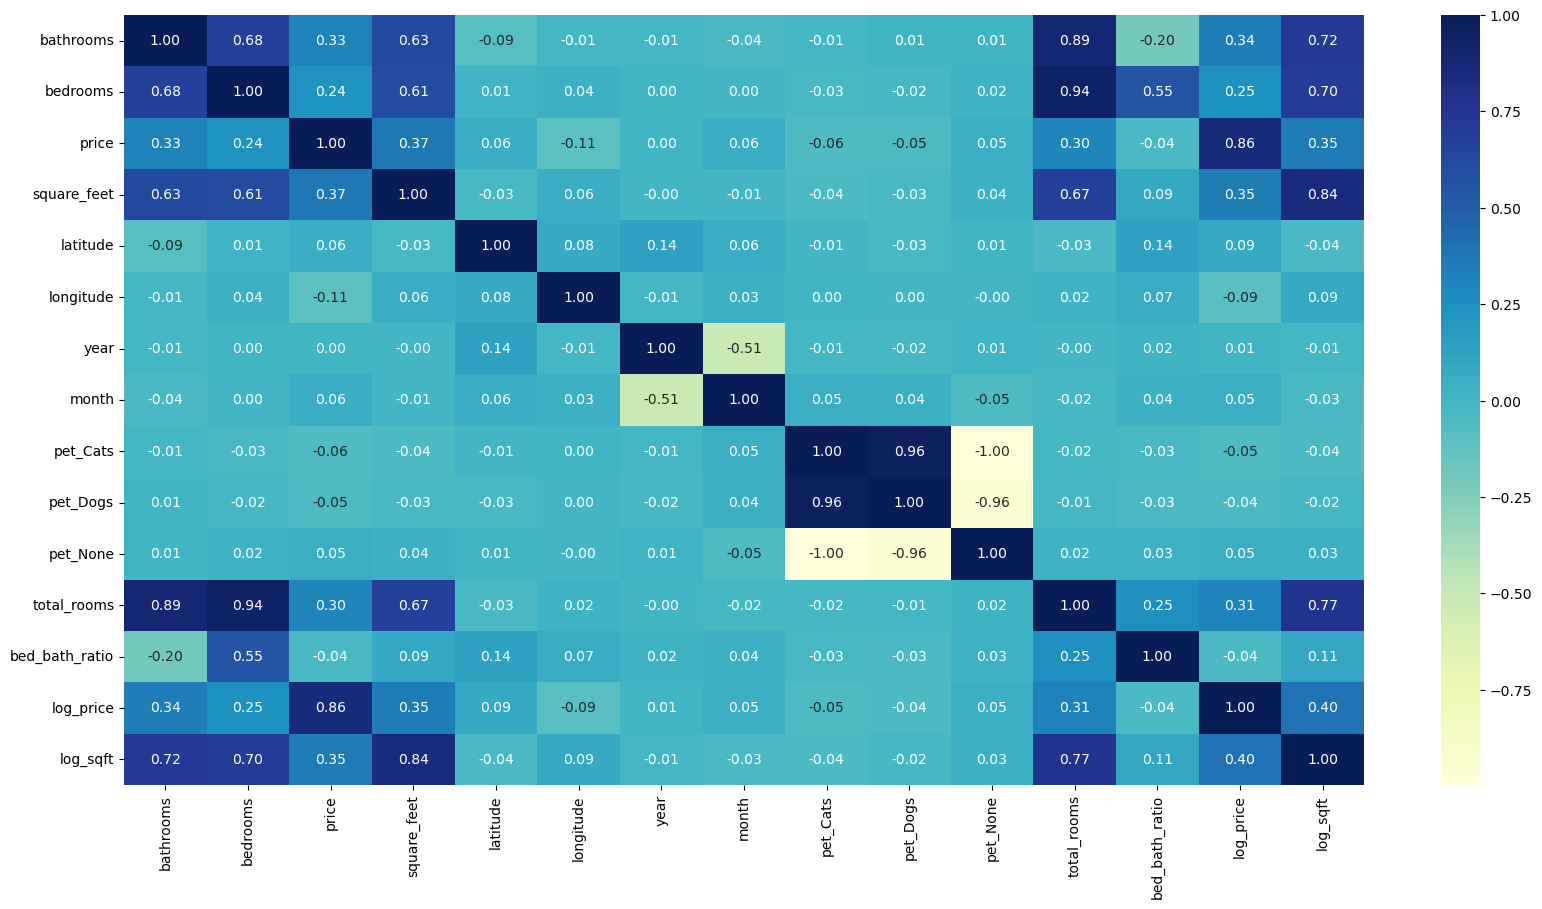

In [44]:
# Split numerical and categorical values
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Plotting the correlation between numerical variables
plt.figure(figsize = (20, 10))
sns.heatmap(df[num_cols].corr(), annot = True, fmt = '0.2f', cmap = 'YlGnBu')

We need to convert the categorical features into numerical ones.

### Encoding categories

In [45]:
# Check has_photo categories
df['has_photo'].unique()

array(['Thumbnail', 'No', 'Yes'], dtype=object)

In [46]:
# One-hot encode has photo with a prefix
df = df.join(df['has_photo'].str.get_dummies().add_prefix('photo_'))

# Drop the 'has_photo' column
df = df.drop(columns=['has_photo'])

Has photo column has been encoded using one-hot encoding, now let's repeat this for amenities.

In [47]:
# Check amenities categories
df['amenities'].unique()

array(['essential', 'expensive'], dtype=object)

In [48]:
# One-hot encode amenities with a prefix
df = df.join(df['amenities'].str.get_dummies().add_prefix('amenities_'))

# Drop the 'amenities' column
df = df.drop(columns=['amenities'])

Now amenities have been successfully one-hot encoded as well.

### Preprocessing Continuous Data and treating outliers

In [49]:
# We assign outliers to the closest whisker value using clamp method
df['square_feet'] = df['square_feet'].clip(lower=lower_whisker_sqrft, upper=upper_whisker_sqrft)

In [50]:
# We assign outliers to the closest whisker value using clamp method
df['price'] = df['price'].clip(lower=lower_whisker, upper=upper_whisker)

## Model building

<b> Data preparation </b>

In [51]:
# Let's have a look at all columns that we have and choose which we will use for modeling
df.columns.tolist()

['bathrooms',
 'bedrooms',
 'price',
 'square_feet',
 'latitude',
 'longitude',
 'time_formatted',
 'year',
 'month',
 'pet_Cats',
 'pet_Dogs',
 'pet_None',
 'total_rooms',
 'bed_bath_ratio',
 'log_price',
 'log_sqft',
 'photo_No',
 'photo_Thumbnail',
 'photo_Yes',
 'amenities_essential',
 'amenities_expensive']

In [52]:
# Seperate independent variables, drop any useless variables
X = df[['bathrooms',
        'bedrooms',
        'square_feet',
        'year',
        'month',
        'pet_Cats',
        'pet_Dogs',
        'pet_None',
        'total_rooms',
        'bed_bath_ratio',
        'log_sqft',
        'photo_No',
        'photo_Thumbnail',
        'photo_Yes',
        'amenities_essential',
        'amenities_expensive']]

# Seperate target variable
y = df['price']

In [53]:
# Check the shape of data
X.shape

(99883, 16)

<b> Partition the data into train and test set </b>

In [54]:
# Split into training and testing data
# Using 15% of data for testing as I will be splitting data into 70/15/15 for train/val/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.15, random_state = 42, shuffle = True)

In [55]:
# Make sure data remains the correct size
print(f"Train {X_train.shape}, Test: {X_test.shape}")

Train (84900, 16), Test: (14983, 16)


In [56]:
# Now split the remaining 85% into train and validation
validation_fraction = 0.15/0.85
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=validation_fraction, random_state=42, shuffle=True)

# Check the sizes
print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")

Train: (69917, 16), Validation: (14983, 16), Test: (14983, 16)


### Scaling Data

Knn algorithm is a distance based algorithm, this means it is sensitive to the scale of the variables. Therefore, we scale our data before applying the algorithm.

In [57]:
# Applying standard scaler on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Transforming validation and testing using scaler from train
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Converting scaled data to a dataframe
df_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
df_scaled.head()

,bathrooms,bedrooms,square_feet,year,month,pet_Cats,pet_Dogs,pet_None,total_rooms,bed_bath_ratio,log_sqft,photo_No,photo_Thumbnail,photo_Yes,amenities_essential,amenities_expensive
0,-0.811223,-0.971488,-1.016574,0.439017,0.392452,1.254470,1.299540,-1.251153,-0.984408,-0.494432,-0.931403,-0.320042,-0.727284,0.884362,-0.67687,0.67687
1,-0.811223,-0.971488,-1.048831,0.439017,0.392452,-0.797149,-0.769503,0.799262,-0.984408,-0.494432,-0.972301,-0.320042,-0.727284,0.884362,-0.67687,0.67687
2,-0.811223,-0.971488,-0.210158,0.439017,0.392452,-0.797149,-0.769503,0.799262,-0.984408,-0.494432,-0.057608,-0.320042,-0.727284,0.884362,-0.67687,0.67687
3,-0.811223,-0.971488,-0.564981,0.439017,-1.393780,1.254470,1.299540,-1.251153,-0.984408,-0.494432,-0.410973,-0.320042,-0.727284,0.884362,-0.67687,0.67687
4,-0.811223,-0.971488,-0.511220,0.439017,0.392452,-0.797149,-0.769503,0.799262,-0.984408,-0.494432,-0.354664,-0.320042,-0.727284,0.884362,-0.67687,0.67687


In [58]:
# Let's check data quality report after scaling the data
data_quality_numeric(df_scaled)

,Count,% Miss,Card.,Min,Q1,Mean,Median,Q3,Max,Std. Dev.
bathrooms,69917.0,0.0,15,-0.811223,-0.811223,1.097567e-16,-0.811223,1.016924,12.899878,1.000007
bedrooms,69917.0,0.0,10,-2.306306,-0.971488,1.018299e-16,0.363330,0.363330,9.707056,1.000007
square_feet,69917.0,0.0,1157,-1.457416,-0.769273,1.953263e-16,-0.152812,0.614180,2.692943,1.000007
year,69917.0,0.0,2,-2.277815,0.439017,-1.395570e-13,0.439017,0.439017,0.439017,1.000007
month,69917.0,0.0,12,-1.648955,-1.393780,-1.022364e-16,0.392452,0.392452,1.157980,1.000007
pet_Cats,69917.0,0.0,2,-0.797149,-0.797149,2.703268e-17,-0.797149,1.254470,1.254470,1.000007
pet_Dogs,69917.0,0.0,2,-0.769503,-0.769503,1.117893e-18,-0.769503,1.299540,1.299540,1.000007
pet_None,69917.0,0.0,2,-1.251153,-1.251153,-3.191075e-17,0.799262,0.799262,0.799262,1.000007
total_rooms,69917.0,0.0,25,-1.824672,-0.984408,5.813042e-17,-0.144144,0.696120,9.518891,1.000007
bed_bath_ratio,69917.0,0.0,35,-2.623214,-0.494432,-3.587419e-16,-0.494432,0.417903,10.149478,1.000007


- Before scaling, square_feet had large numeric variation, ranging from ~530 to ~1700 sqrft.
- After scaling, mean is near 0 and std. dev is about 1, ensuring that square footage no longer dominates smaller-valued features such as bedrooms and bathrooms.
- This is crucial for Knn, where distances would otherwise be driven almost entirely by square_feet. Scaling ensures all features contribute proportionally to similarity calculations.

In [59]:
# Creating metrics function for evaluation
def metrics(actual, predicted, dataset_name):
    mae = mean_absolute_error(actual, predicted)
    mape = mean_absolute_percentage_error(actual, predicted) * 100
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)
    
    return {'Dataset': dataset_name, 'MAE': mae, 'MAPE (%)': mape, 'RMSE': rmse, 'R²': r2}

In [82]:
# We will need to evaluate models on train, val, test sets
def evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_tesvt, model_name):
    results = []
    
    # Training set
    y_train_pred = model.predict(X_train)
    results.append(metrics(y_train, y_train_pred, 'Train'))
    
    # Validation set
    y_val_pred = model.predict(X_val)
    results.append(metrics(y_val, y_val_pred, 'Validation'))
    
    # Test set
    y_test_pred = model.predict(X_test)
    results.append(metrics(y_test, y_test_pred, 'Test'))
    
    # Create DataFrame
    df_results = pd.DataFrame(results)
    df_results.insert(0, 'Model', model_name)
    
    return df_results

In [61]:
# Store all results for different models here
all_results = []

In [62]:
# KNN - K-Nearest Neighbours
print("Training KNN...")
# Default values for knn parameters are n_neighbors=5 and weights='uniform'
knn_selection = [{'n_neighbors': 3, 'weights': 'uniform'},
                 {'n_neighbors': 5, 'weights': 'uniform'},
                 {'n_neighbors': 10, 'weights': 'uniform'}]

for params in knn_selection:
    # Model with hyperparameters
    knn = KNeighborsRegressor(**params)
    # Train on training set
    knn.fit(X_train_scaled, y_train)
    # Set model name to show k value
    model_name = f"KNN (k={params['n_neighbors']})"
    
    results = evaluate_model(knn, X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test, model_name)
    all_results.append(results)

# Add to final results table
final_results = pd.concat(all_results, ignore_index=True)

Training KNN...


In [63]:
# Decision Tree
print("Training Decision Tree...")
# Default values for decision tree parameters are max_depth=None
dt_selection = [{'max_depth': 5, 'random_state': 42},
                {'max_depth': 10, 'random_state': 42},
                {'max_depth': None, 'random_state': 42}]

for params in dt_selection:
    # Model with hyperparameters
    dt = DecisionTreeRegressor(**params)
    # Train on training set
    dt.fit(X_train_scaled, y_train)
    # Set model name to show depth values
    model_name = f"Decision tree (depth={params['max_depth']})"
    
    results = evaluate_model(dt, X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test, model_name)
    all_results.append(results)


# Add to final results table
final_results = pd.concat(all_results, ignore_index=True)

Training Decision Tree...


In [64]:
# Random Forest
print("Training Random Forest...")
# Default values for random forest parameters are n_estimators=100 and max_depth=None
rf_selection = [{'n_estimators': 100, 'max_depth': 10, 'random_state': 42},
                {'n_estimators': 200, 'max_depth': 15, 'random_state': 42},
                {'n_estimators': 300, 'max_depth': None, 'random_state': 42}]

for params in rf_selection:
    # Model with hyperparameters
    rf = RandomForestRegressor(**params)
    # Train on training set
    rf.fit(X_train_scaled, y_train)
    # Set model name to show params values
    model_name = f"Random Forest (n={params['n_estimators']}, depth={params['max_depth']})"
    
    results = evaluate_model(rf, X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test, model_name)
    all_results.append(results)


# Add to final results table
final_results = pd.concat(all_results, ignore_index=True)

Training Random Forest...


In [65]:
final_results.sort_values(by=['Dataset','MAE'])

,Model,Dataset,MAE,MAPE (%),RMSE,R²
26,"Random Forest (n=300, depth=None)",Test,407.718914,30.499375,547.474194,0.200885
23,"Random Forest (n=200, depth=15)",Test,411.228731,30.891440,530.214166,0.250478
20,"Random Forest (n=100, depth=10)",Test,425.634507,32.048405,540.671305,0.220622
8,KNN (k=10),Test,428.483685,31.906068,553.934086,0.181916
14,Decision tree (depth=10),Test,432.588031,32.516339,552.510378,0.186116
5,KNN (k=5),Test,434.079864,32.287962,567.630058,0.140962
17,Decision tree (depth=None),Test,438.545841,32.447502,613.652876,-0.003985
11,Decision tree (depth=5),Test,440.558315,33.257130,556.235177,0.175105
2,KNN (k=3),Test,444.207280,32.946942,590.038753,0.071797
15,Decision tree (depth=None),Train,205.802787,15.642709,345.300147,0.677913


<b> Observations: </b>
- Random Forest models consistently delivered the best performance, achieving the lowest MAE and highest R² values across all datasets compared to both KNN and Decision Tree models. This highlights the strength of ensemble methods in this regression task.

- K-Nearest Neighbors (KNN): Performance improved as k increased from 3 to 10, with k=10 yielding the lowest test MAE of $428.36. KNN generalization is limited, as indicated by low R² and high MAPE, showing the model struggles to capture underlying patterns.

- Decision Trees: A max_depth of 10 offered a reasonable balance. However, the model with unlimited depth (max_depth=None) exhibited severe overfitting. Training MAE was exceptionally low ($205.80), but validation and test performance was poor, even resulting in a negative R², meaning it performed worse than a simple benchmark on unseen data.

- Random Forest: Performance generally improved with a higher number of estimators (n_estimators) and deeper trees, demonstrating the model's ability to capture more complexity without significant overfitting.

- The final model was selected by prioritizing the Mean Absolute Error (MAE) on the validation set, as it provides the most direct and interpretable measure of average price prediction error. Based on this criterion, the Random Forest model with n_estimators=300 and max_depth=None was identified as optimal, achieving the lowest validation MAE of $405.03.

- Note that while this model excelled in MAE, its validation R² (0.197) and RMSE (547.32) were inferior to other Random Forest configurations. This trade-off was deemed acceptable, as minimizing the average dollar error was the primary business objective for this modeling phase.

The performance of this final selected model on the unseen test set was:

- Mean Absolute Error (MAE): $407.72

- Mean Absolute Percentage Error (MAPE): 30.50%

- Root Mean Squared Error (RMSE): $547.47

- R-squared (R²): 0.201
 

In practical terms, an MAE of approximately 408 USD means that, on average, the model's price predictions deviate from the actual rental price by about 408 USD.

In [66]:
# Create benchmark predictions for comparisson
# Use mean of training set as the constant prediction
y_train_mean = y_train.mean()
y_pred_train_benchmark = [y_train_mean] * len(y_train)
y_pred_val_benchmark = [y_train_mean] * len(y_val)
y_pred_test_benchmark = [y_train_mean] * len(y_test)

results = []

# Append benchmark results to your results list
results.append(metrics(y_train, y_pred_train_benchmark, 'Training'))
results.append(metrics(y_val, y_pred_val_benchmark, 'Validation'))
results.append(metrics(y_test, y_pred_test_benchmark, 'Testing'))

In [67]:
# Print a dataframe for benchmark
results_df = pd.DataFrame(results)
results_df.sort_values(by=['Dataset','MAE'])

,Dataset,MAE,MAPE (%),RMSE,R²
2,Testing,485.438831,37.748813,612.442639,-0.000029
0,Training,482.066288,37.636598,608.429621,0.000000
1,Validation,483.996373,37.814117,610.761606,-0.000027


<b> Observations: </b>
- All models that we have tested before outperform the benchmark model.
- The benchmark provides essentially no explanatory power (R² = ~0) and relatively high prediction errors.
- Random Forest clearly outperforms all other models across all metrics, especially in MAE and MAPE.
- KNN improves over benchmark MAE, but its R² remains extremely low which means that predictions are still not well-correlated with true prices.
- Decision Trees either overfit (unlimited depth) or perform roughly at benchmark level (max_depth = 10).
- Random Forest reduced average prediction error significantly ~64 USD compared to benchmark, which is significant in real world terms.

# Regression using ANN

In [99]:
# Import Keras libraries and packages
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import BinaryCrossentropy

In [117]:
# Small Architecture (fast, low-capacity)
# Input -> Dense(64) -> Dense(32) -> Out(1)

# Set to the most common and stable baseline step size
l2 = 1e-3
# Each training step randomly ignores 20% of neurons in that layer
dropout = 0.2

model = Sequential()

# Input layer
model.add(Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(l2), input_dim=16))
# Normalises the outputs of a layer for each mini-batch, then scales and shifts them using learnable parameters
model.add(BatchNormalization())
model.add(Dropout(dropout))

# Hidden layer
model.add(Dense(32, activation='relu', kernel_regularizer=regularizers.l2(l2)))
model.add(BatchNormalization())
model.add(Dropout(dropout))

# Output layer (1 neuron for regression)
model.add(Dense(1, activation='linear'))

# Compile using mse for loss because it's stable by punishing large errors heavily
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Implementing early stopping to automatically stop when validation stops improving
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# Train (with validation)
history = model.fit(x=X_train_scaled,
                    y=y_train,
                    validation_data=(X_val_scaled, y_val),
                    batch_size=64,
                    epochs=200,
                    verbose=1,
                    callbacks=[early_stop])

Epoch 1/200
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 2514804.7500 - mae: 1467.0065 - val_loss: 2282532.5000 - val_mae: 1398.2350
Epoch 2/200
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 2124625.5000 - mae: 1341.8258 - val_loss: 1667392.3750 - val_mae: 1168.3350
Epoch 3/200
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1521511.7500 - mae: 1101.0544 - val_loss: 1070915.0000 - val_mae: 880.5358
Epoch 4/200
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 945271.1875 - mae: 802.0500 - val_loss: 600733.6250 - val_mae: 581.8829
Epoch 5/200
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 535275.5625 - mae: 540.2455 - val_loss: 367755.6875 - val_mae: 438.1349
Epoch 6/200
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 365681.7500 - mae: 446.2013 - val_loss: 307410.7188 - val_mae: 425.7590
Epoch 7/200
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 321665.5625 - mae: 439.3467 - val_loss: 301200.3125 - val_mae: 431.0877
Epoch 8/200
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 3

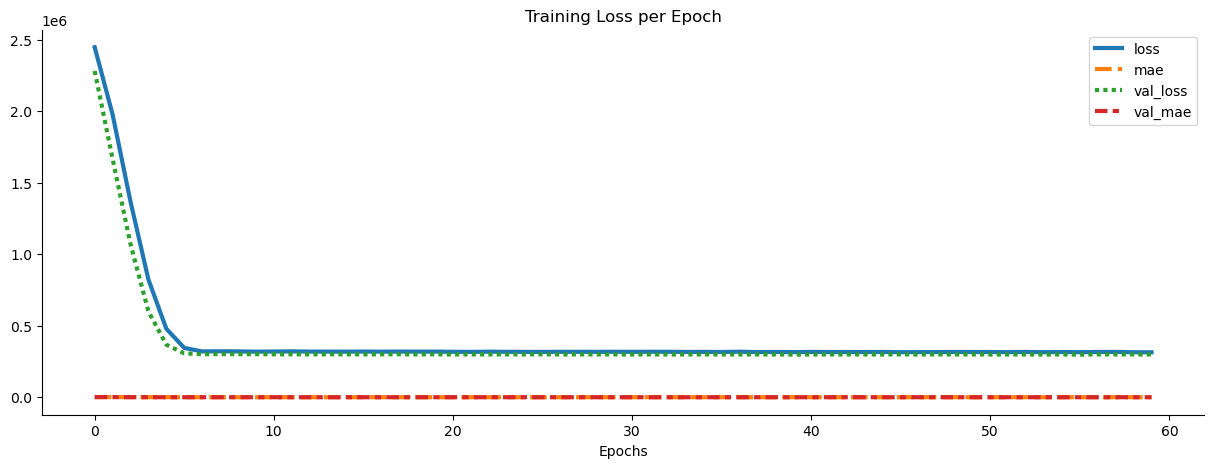

In [118]:
losses = pd.DataFrame(model.history.history)

plt.figure(figsize=(15,5))
sns.lineplot(data=losses,lw=3)
plt.xlabel('Epochs')
plt.ylabel('')
plt.title('Training Loss per Epoch')
sns.despine()

<b> Observations: </b>
- The small model architecture included two hidden layers with 64 and 32 neurons respectively, using ReLU activation, L2 regularization, Dropout (0.2), and Batch Normalization. The network was trained with the Adam optimizer, MSE loss, and MAE metric.
- Training and validation Loss both plateaued at ~0.4 and are nearly identical.
- Training and validation MAE are similar, indicating consistent performance.
- The model generalizes well (no overfitting) but underfits, as the error is still noticeable.
- Current architecture cannot capture all data patterns, increasing model capacity or improving features may reduce error.
- We need to add layers and neurons, tune hyperparameters, or enhance input features.

In [119]:
# Make predictions with small model
predictions_train = model.predict(X_train_scaled)
predictions_val = model.predict(X_val_scaled)
predictions_test = model.predict(X_test_scaled)

# Make empty list
results = []

# Add your small model’s performance
results.append(metrics(y_train, predictions_train, 'Training_Small_ANN'))
results.append(metrics(y_val, predictions_val, 'Validation_Small_ANN'))
results.append(metrics(y_test, predictions_test, 'Testing_Small_ANN'))

2185/2185 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step  
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 811us/step


In [120]:
# Convert results to DataFrame for a cleaner display
results_df = pd.DataFrame(results)
results_df.sort_values(by=['Dataset','MAE'])

,Dataset,MAE,MAPE (%),RMSE,R²
2,Testing_Small_ANN,432.622029,32.621649,547.179012,0.201747
0,Training_Small_ANN,429.450055,32.408890,542.886433,0.203846
1,Validation_Small_ANN,431.610333,32.564298,546.375280,0.199704


In [121]:
# Medium Architecture (default starting point)
# Input -> Dense(256) -> Dense(128) -> Dense(64) -> Out(1)

# Set to the most common and stable baseline step size
l2 = 1e-3
# Each training step randomly ignores 20% of neurons in that layer
dropout = 0.2

model = Sequential()

# Input layer
model.add(Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(l2), input_dim=16))
# Normalises the outputs of a layer for each mini-batch, then scales and shifts them using learnable parameters
model.add(BatchNormalization())
model.add(Dropout(dropout))

# Hidden layer
model.add(Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(l2)))
model.add(BatchNormalization())
model.add(Dropout(dropout))
model.add(Dense(64, activation='relu', kernel_regularizer=regularizers.l2(l2)))
model.add(BatchNormalization())
model.add(Dropout(dropout))

# Output layer (1 neuron for regression)
model.add(Dense(1, activation='linear'))

# Compile using mse for loss because it's stable by punishing large errors heavily
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Implementing early stopping to automatically stop when validation stops improving
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# Train (with validation)
history = model.fit(x=X_train_scaled,
                    y=y_train,
                    validation_data=(X_val_scaled, y_val),
                    batch_size=64,
                    epochs=200,
                    verbose=1,
                    callbacks=[early_stop])

Epoch 1/200
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 2478921.0000 - mae: 1458.5135 - val_loss: 2049267.7500 - val_mae: 1319.3800
Epoch 2/200
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1803068.5000 - mae: 1220.9298 - val_loss: 1134710.2500 - val_mae: 915.3679
Epoch 3/200
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 942754.1250 - mae: 799.4662 - val_loss: 492400.0312 - val_mae: 508.1225
Epoch 4/200
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 429955.1562 - mae: 475.5902 - val_loss: 314551.7500 - val_mae: 422.9357
Epoch 5/200
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 316138.3750 - mae: 431.8943 - val_loss: 300298.3125 - val_mae: 430.8343
Epoch 6/200
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 311229.3125 - mae: 439.9704 - val_loss: 300414.0312 - val_mae: 431.8665
Epoch 7/200
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 312374.8125 - mae: 440.1603 - val_loss: 299005.5312 - val_mae: 431.1536
Epoch 8/200
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 3s 3

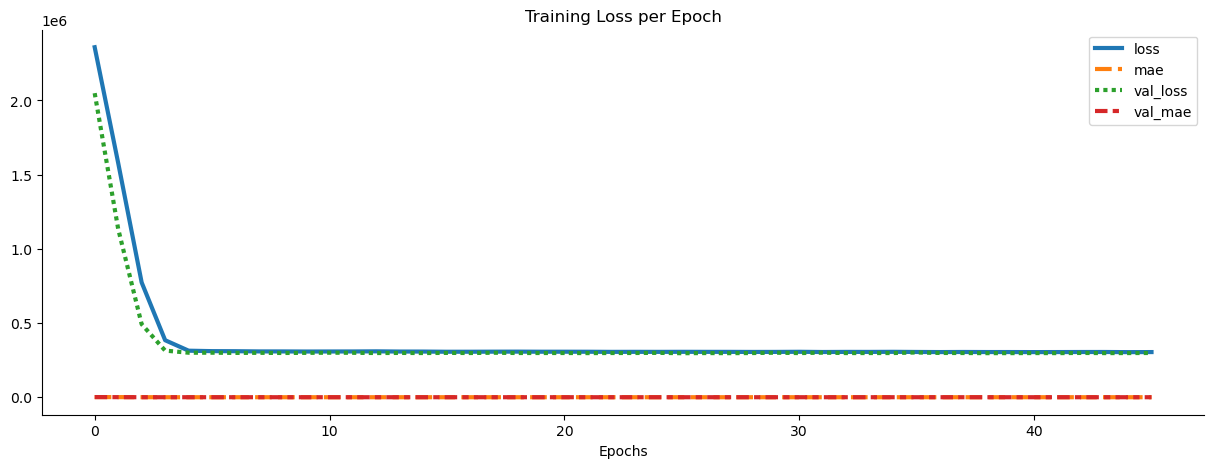

In [122]:
losses = pd.DataFrame(model.history.history)

plt.figure(figsize=(15,5))
sns.lineplot(data=losses,lw=3)
plt.xlabel('Epochs')
plt.ylabel('')
plt.title('Training Loss per Epoch')
sns.despine()

<b> Observations: </b>
- The medium ANN with 3 hidden layers generalizes well, with training and validation loss nearly identical. The network has learned patterns from the training set that also apply well to unseen validation data.
- Slight under-training suggests stable learning, but further accuracy improvements may require a larger or more optimized architecture.

In [123]:
# Make predictions with medium model
predictions_train = model.predict(X_train_scaled)
predictions_val = model.predict(X_val_scaled)
predictions_test = model.predict(X_test_scaled)

# Add medium model’s performance
results.append(metrics(y_train, predictions_train, 'Training_Medium_ANN'))
results.append(metrics(y_val, predictions_val, 'Validation_Medium_ANN'))
results.append(metrics(y_test, predictions_test, 'Testing_Medium_ANN'))

2185/2185 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 910us/step


In [124]:
# Convert results to DataFrame for a cleaner display
results_df = pd.DataFrame(results)
results_df.sort_values(by=['Dataset','MAE'])

,Dataset,MAE,MAPE (%),RMSE,R²
5,Testing_Medium_ANN,429.624740,32.202223,546.134011,0.204793
2,Testing_Small_ANN,432.622029,32.621649,547.179012,0.201747
3,Training_Medium_ANN,425.458095,31.907814,540.535279,0.210727
0,Training_Small_ANN,429.450055,32.408890,542.886433,0.203846
4,Validation_Medium_ANN,428.456660,32.110328,545.001367,0.203724
1,Validation_Small_ANN,431.610333,32.564298,546.375280,0.199704


In [125]:
# Large Architecture (if underfitting or lots of nonlinearity)
# Input -> Dense(512) -> Dense(256) -> Dense(128) -> Dense(64) -> Out(1)

# Set to the most common and stable baseline step size
l2 = 1e-3
# Each training step randomly ignores 20% of neurons in that layer
dropout = 0.2

model = Sequential()

# Input layer
model.add(Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(l2), input_dim=16))
# Normalises the outputs of a layer for each mini-batch, then scales and shifts them using learnable parameters
model.add(BatchNormalization())
model.add(Dropout(dropout))

# Hidden layer
model.add(Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(l2)))
model.add(BatchNormalization())
model.add(Dropout(dropout))
model.add(Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(l2)))
model.add(BatchNormalization())
model.add(Dropout(dropout))
model.add(Dense(64, activation='relu', kernel_regularizer=regularizers.l2(l2)))
model.add(BatchNormalization())
model.add(Dropout(dropout))

# Output layer (1 neuron for regression)
model.add(Dense(1, activation='linear'))

# Compile using mse for loss because it's stable by punishing large errors heavily
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Implementing early stopping to automatically stop when validation stops improving
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# Train (with validation)
history = model.fit(x=X_train_scaled,
                    y=y_train,
                    validation_data=(X_val_scaled, y_val),
                    batch_size=64,
                    epochs=200,
                    verbose=1,
                    callbacks=[early_stop])

Epoch 1/200
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 2478076.5000 - mae: 1457.1932 - val_loss: 2015583.8750 - val_mae: 1307.4741
Epoch 2/200
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1810147.0000 - mae: 1222.3835 - val_loss: 1137431.0000 - val_mae: 917.5163
Epoch 3/200
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 938075.4375 - mae: 796.9673 - val_loss: 504909.0938 - val_mae: 519.1109
Epoch 4/200
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 434496.9688 - mae: 479.5896 - val_loss: 315281.6250 - val_mae: 423.1652
Epoch 5/200
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 317668.3125 - mae: 432.5756 - val_loss: 302029.6250 - val_mae: 430.7953
Epoch 6/200
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 311543.8438 - mae: 438.9326 - val_loss: 300406.2188 - val_mae: 431.6895
Epoch 7/200
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 312068.5625 - mae: 440.3219 - val_loss: 299548.4688 - val_mae: 432.9416
Epoch 8/200
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 4s 3

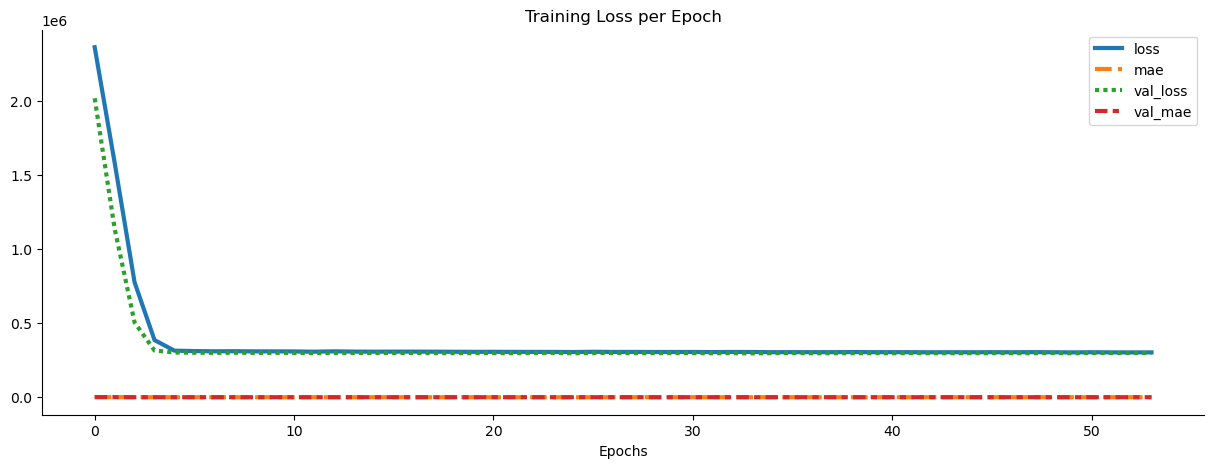

In [126]:
losses = pd.DataFrame(model.history.history)

plt.figure(figsize=(15,5))
sns.lineplot(data=losses,lw=3)
plt.xlabel('Epochs')
plt.ylabel('')
plt.title('Training Loss per Epoch')
sns.despine()

In [127]:
# Make predictions with large model
predictions_train = model.predict(X_train_scaled)
predictions_val = model.predict(X_val_scaled)
predictions_test = model.predict(X_test_scaled)

# Add large model’s performance
results.append(metrics(y_train, predictions_train, 'Training_Large_ANN'))
results.append(metrics(y_val, predictions_val, 'Validation_Large_ANN'))
results.append(metrics(y_test, predictions_test, 'Testing_Large_ANN'))

2185/2185 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 884us/step


In [128]:
# Convert results to DataFrame for a cleaner display
results_df = pd.DataFrame(results)
results_df.sort_values(by=['Dataset','MAE'])

,Dataset,MAE,MAPE (%),RMSE,R²
8,Testing_Large_ANN,431.265183,32.576066,545.857842,0.205597
5,Testing_Medium_ANN,429.624740,32.202223,546.134011,0.204793
2,Testing_Small_ANN,432.622029,32.621649,547.179012,0.201747
6,Training_Large_ANN,426.015443,32.196210,538.628948,0.216284
3,Training_Medium_ANN,425.458095,31.907814,540.535279,0.210727
0,Training_Small_ANN,429.450055,32.408890,542.886433,0.203846
7,Validation_Large_ANN,429.739694,32.450130,544.099405,0.206358
4,Validation_Medium_ANN,428.456660,32.110328,545.001367,0.203724
1,Validation_Small_ANN,431.610333,32.564298,546.375280,0.199704


In [154]:
# Large Architecture with lower dropout
# Input -> Dense(512) -> Dense(256) -> Dense(128) -> Dense(64) -> Out(1)

# Architecture parameters
dropout = 0.1
l2 = 1e-4  # mild L2 regularization to stabilize deeper model

model = Sequential()

# Input layer
model.add(Dense(512, kernel_regularizer=regularizers.l2(l2), input_dim=16))
model.add(LeakyReLU(alpha=0.1))
model.add(BatchNormalization())
model.add(Dropout(dropout))

# Hidden layers
model.add(Dense(256, kernel_regularizer=regularizers.l2(l2)))
model.add(LeakyReLU(alpha=0.1))
model.add(BatchNormalization())
model.add(Dropout(dropout))
model.add(Dense(128, kernel_regularizer=regularizers.l2(l2)))
model.add(LeakyReLU(alpha=0.1))
model.add(BatchNormalization())
model.add(Dropout(dropout))
model.add(Dense(64, kernel_regularizer=regularizers.l2(l2)))
model.add(LeakyReLU(alpha=0.1))
model.add(BatchNormalization())
model.add(Dropout(dropout))


# Output layer (1 neuron for regression)
model.add(Dense(1, activation='linear'))

# Define Adam optimizer with a custom learning rate
optimizer = Adam(learning_rate=0.0005)

# Compile using mse for loss because it's stable by punishing large errors heavily
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Implementing early stopping to automatically stop when validation stops improving
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# Train (with validation)
history = model.fit(x=X_train_scaled,
                    y=y_train,
                    validation_data=(X_val_scaled, y_val),
                    batch_size=64,
                    epochs=200,
                    verbose=1,
                    callbacks=[early_stop])

Epoch 1/200
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 2482603.0000 - mae: 1459.1072 - val_loss: 2031836.2500 - val_mae: 1315.2457
Epoch 2/200
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1800701.0000 - mae: 1220.2603 - val_loss: 1131916.6250 - val_mae: 913.6075
Epoch 3/200
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 938601.3125 - mae: 798.4656 - val_loss: 488239.1250 - val_mae: 506.7927
Epoch 4/200
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 426495.0625 - mae: 472.4378 - val_loss: 312576.3125 - val_mae: 424.9225
Epoch 5/200
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 309414.8438 - mae: 427.8312 - val_loss: 302783.5625 - val_mae: 431.8218
Epoch 6/200
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 306013.1250 - mae: 436.1186 - val_loss: 300631.5625 - val_mae: 433.6569
Epoch 7/200
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 301858.1562 - mae: 434.3451 - val_loss: 299349.8438 - val_mae: 433.7224
Epoch 8/200
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 4s 

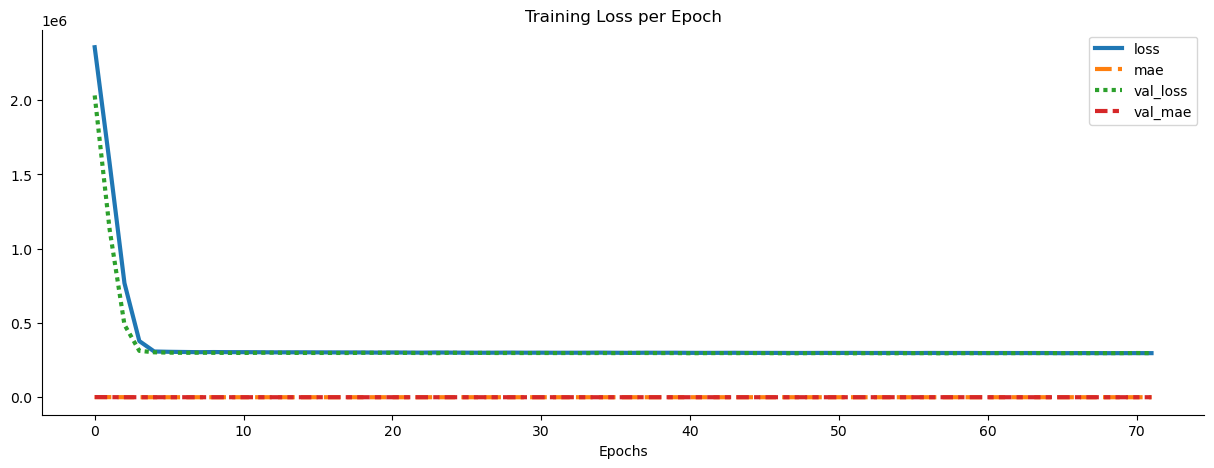

In [155]:
losses = pd.DataFrame(model.history.history)

plt.figure(figsize=(15,5))
sns.lineplot(data=losses,lw=3)
plt.xlabel('Epochs')
plt.ylabel('')
plt.title('Training Loss per Epoch')
sns.despine()

In [157]:
# Make predictions with new large model
predictions_train = model.predict(X_train_scaled)
predictions_val = model.predict(X_val_scaled)
predictions_test = model.predict(X_test_scaled)

# Add large model’s performance
results.append(metrics(y_train, predictions_train, 'Training_Large_ANN_LeakyRelu'))
results.append(metrics(y_val, predictions_val, 'Validation_Large_ANN_LeakyRelu'))
results.append(metrics(y_test, predictions_test, 'Testing_Large_ANN_LeakyRelu'))

2185/2185 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step  
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 884us/step
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 875us/step


In [158]:
# Convert results to DataFrame for a cleaner display
results_df = pd.DataFrame(results)
results_df.sort_values(by=['Dataset','MAE'])

,Dataset,MAE,MAPE (%),RMSE,R²
8,Testing_Large_ANN,431.265183,32.576066,545.857842,0.205597
11,Testing_Large_ANN_LeakyRelu,429.489391,32.234700,545.516443,0.206590
5,Testing_Medium_ANN,429.624740,32.202223,546.134011,0.204793
2,Testing_Small_ANN,432.622029,32.621649,547.179012,0.201747
6,Training_Large_ANN,426.015443,32.196210,538.628948,0.216284
9,Training_Large_ANN_LeakyRelu,424.326752,31.876531,538.484177,0.216705
3,Training_Medium_ANN,425.458095,31.907814,540.535279,0.210727
0,Training_Small_ANN,429.450055,32.408890,542.886433,0.203846
7,Validation_Large_ANN,429.739694,32.450130,544.099405,0.206358
10,Validation_Large_ANN_LeakyRelu,428.097405,32.110683,544.105520,0.206340


<b> Observations: </b>
- Performance across all models is similar, with MAE around ~430 and R² roughly 0.20–0.21, indicating that while the ANN captures some data trends, it struggles to model complex nonlinearities in this dataset.
- The LeakyReLU variant achieved the best results overall, slightly improving across all metrics compared to standard ReLU networks.
- This improvement shows that LeakyReLU helped mitigate the “dying ReLU” problem, allowing more consistent gradient flow during training.
- Reducing dropout from 0.2 to 0.1 and lowering L2 regularization (1e-4) also contributed positively, helping to counter previous underfitting caused by excessive regularization.
- The learning rate of 0.0005 provided a smoother convergence than the default Adam rate (0.001), balancing stability and speed of training.
- The Large architecture (512–256–128–64–1) consistently performed as well or better than smaller networks, confirming that a deeper model was beneficial once regularization was tuned correctly.
- Despite these optimizations, the overall performance of ANNs remained slightly inferior to the Random Forest baseline (MAE ≈ 405, R² ≈ 0.20 vs. 0.19–0.21 for ANN).
- This suggests that the structured, tabular nature of the dataset is better suited to tree-based models, which handle feature interactions and nonlinearity more efficiently without heavy tuning.

## Visualisation

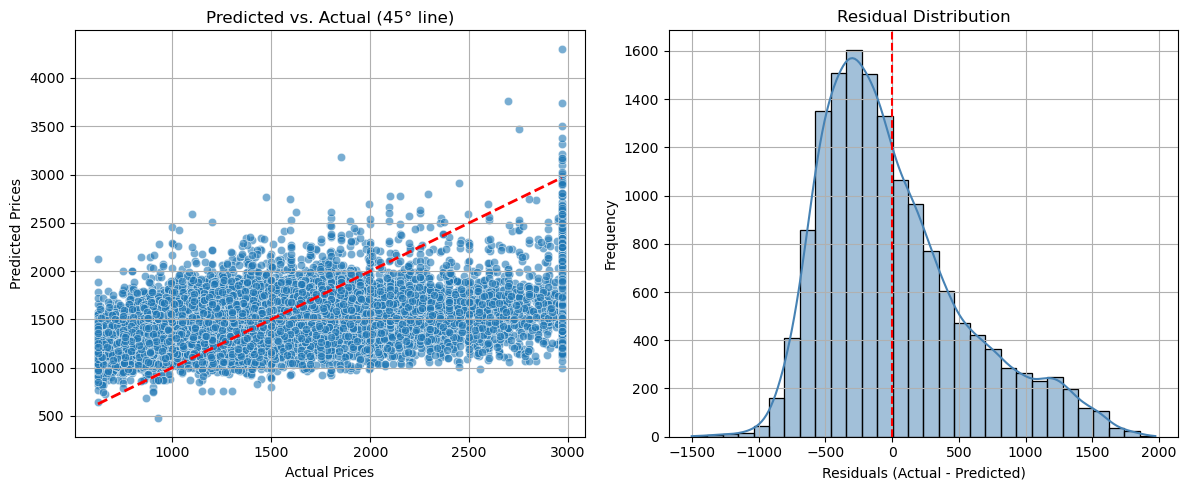

In [162]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Flatten to 1D
y_test_flat = np.ravel(y_test)
predictions_flat = np.ravel(predictions_test)
residuals = y_test_flat - predictions_flat

# Create two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Predicted vs Actual
sns.scatterplot(x=y_test_flat, y=predictions_flat, alpha=0.6, ax=axes[0])
axes[0].plot([y_test_flat.min(), y_test_flat.max()],
             [y_test_flat.min(), y_test_flat.max()],
             'r--', lw=2)
axes[0].set_xlabel("Actual Prices")
axes[0].set_ylabel("Predicted Prices")
axes[0].set_title("Predicted vs. Actual (45° line)")
axes[0].grid(True)

# Residual Distribution
sns.histplot(residuals, kde=True, bins=30, color='steelblue', ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel("Residuals (Actual - Predicted)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Residual Distribution")
axes[1].grid(True)

plt.tight_layout()
plt.show()


<b> Observations: </b>
- Predicted vs. Actual plot shows clustered predictions that are mostly flat, indicating underfitting.
- Slight upward trend suggests some correlation, but model struggles to capture full price variability.
- Residuals roughly bell-shaped but slightly left-skewed, with minor overestimation for low prices and underestimation for high prices.
- Residuals mostly centred around zero, so systematic bias is limited.